#Loan Default Risk Analysis
##Notebook 03 — Exploratory Data Analysis
###Sector: Finance — Mortgage & Loan Portfolio
####Dataset: 15,000 borrower records | 34 features | 2019
Objective:
To explore the loan dataset through distributions, trends, and visual analysis — identifying key patterns, risk segments, and behavioural factors that contribute to loan default.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df  = pd.read_csv("loan_final_cleaned.csv")

In [3]:
def default_rate_by(col, df):
    result = df.groupby(col)['status'].agg(
        count='count',
        defaults='sum'
    ).reset_index()
    result['default_rate_%'] = (result['defaults'] / result['count'] * 100).round(1)
    return result

palette = {0: '#5fba7d', 1: '#d65f5f'}

## Section: Target Variable Distribution

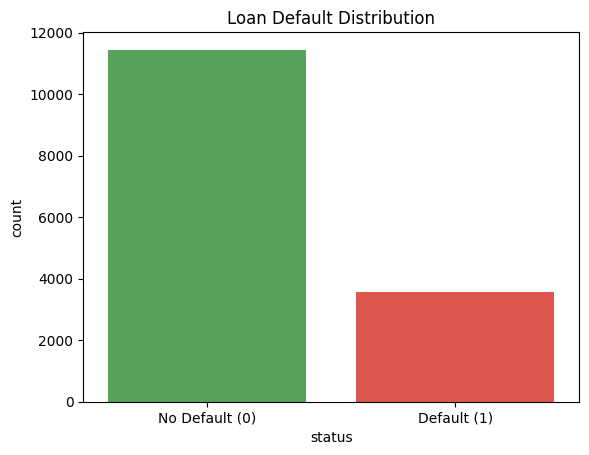

,proportion
status,
0,0.7628
1,0.2372


In [23]:
palette = {0: "#4CAF50", 1: "#F44336"}
sns.countplot(x='status',hue='status', data=df, palette=palette,legend=False)
plt.title("Loan Default Distribution")
plt.xticks([0, 1], ['No Default (0)', 'Default (1)'])
plt.show()
df['status'].value_counts(normalize=True)

### 📊 Observation:
The dataset is imbalanced, with a higher proportion of non-default cases compared to default cases.

### 💡 Insight:
23.7% of borrowers defaulted — nearly 1 in 4 loans. This elevated default rate signals a systemic risk in the portfolio that cannot be addressed through isolated borrower-level checks alone. A portfolio-wide risk policy review is warranted.

## Section: Distributions

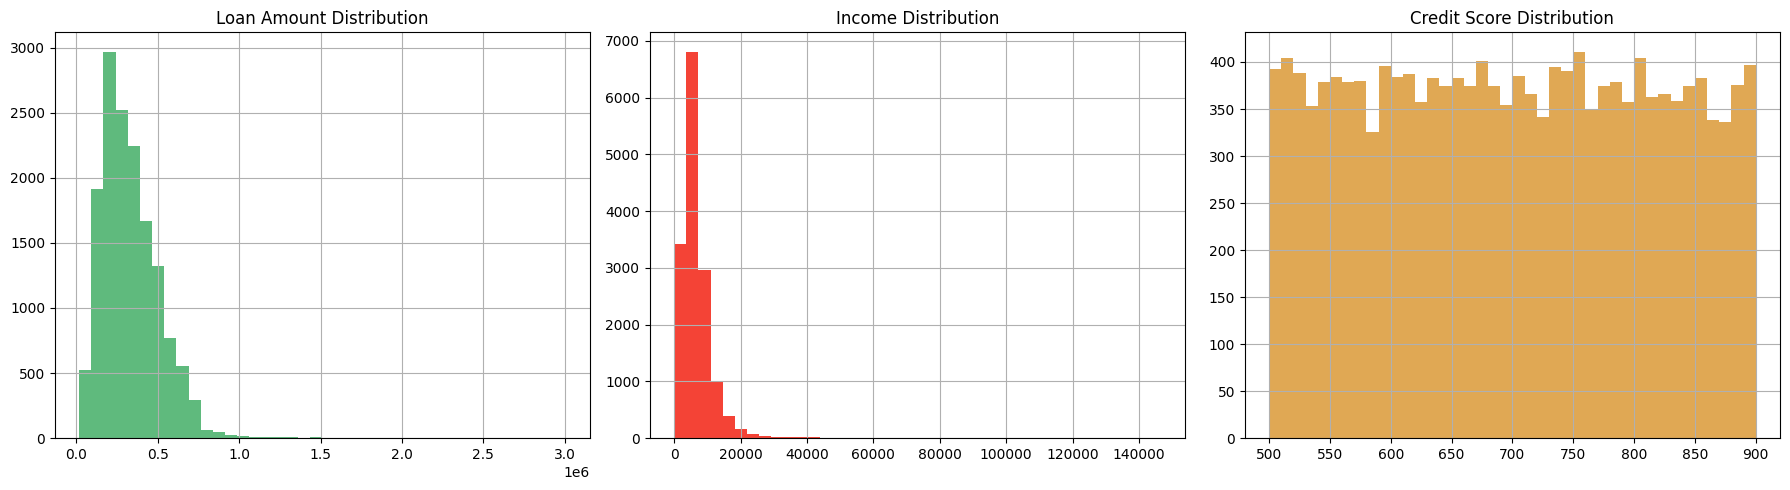

Loan Amount Skewness: 1.819330869057952
Income Skewness: 7.362443854507835


In [5]:

fig, axes = plt.subplots(1, 3, figsize=(18,5))
df['loan_amount'].hist(ax=axes[0], bins=40,color='#5fba7d')
axes[0].set_title('Loan Amount Distribution')

df['income'].hist(ax=axes[1], bins=40,color="#F44336")
axes[1].set_title('Income Distribution')

df['credit_score'].hist(ax=axes[2], bins=40,color='#E0A854')
axes[2].set_title('Credit Score Distribution')

plt.tight_layout()
plt.show()

# Skewness
print("Loan Amount Skewness:", df['loan_amount'].skew())
print("Income Skewness:", df['income'].skew())

### 📊 Observation:
Loan amount skewness is 1.82 and income skewness is 7.36 — both heavily right-skewed. Credit score is uniformly distributed across 500–900.
### 💡 Insight:
Mean income is not representative due to extreme skew — a few high earners distort the average. The flat credit score distribution explains why it shows near-zero correlation with default — no score band carries meaningfully higher risk.

## Section: Numerical Features vs Default Status

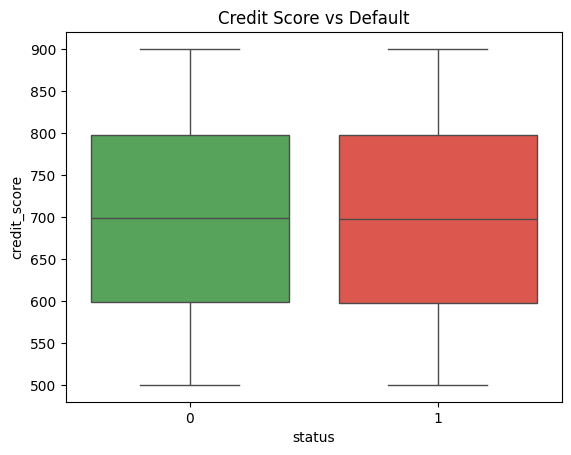

In [6]:
sns.boxplot(x='status', y='credit_score', data=df,hue='status',palette=palette,legend=False)
plt.title("Credit Score vs Default")
plt.show()

### 📊 Observation:
Credit score distributions for default and non-default groups show significant overlap.

### 💡 Insight:
Contrary to common expectations, credit score alone has limited discriminatory power in this dataset.
This suggests that relying solely on credit score may not be sufficient for identifying risky borrowers.

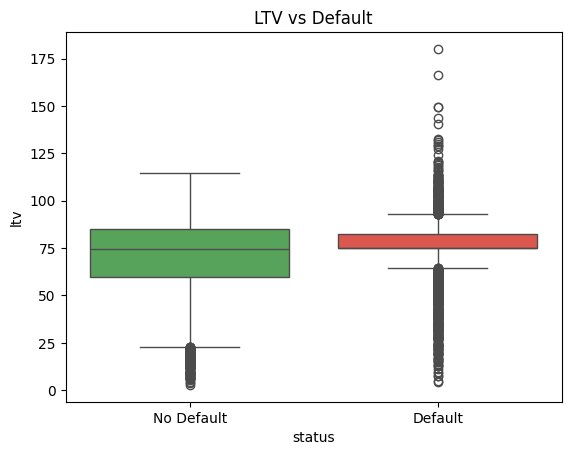

In [24]:
sns.boxplot(x='status', y='ltv', data=df,hue='status',palette=palette,legend=False)
plt.title("LTV vs Default")
plt.xticks([0, 1], ['No Default', 'Default'])
plt.show()

### 📊 Observation:
Defaulted borrowers show slightly higher median LTV and considerably greater variability, with notable outliers exceeding 125% LTV — indicating loans where the outstanding balance exceeds the property value.
### 💡 Insight:
Defaulted borrowers carry slightly higher LTV, indicating lower equity in the property. While the difference is modest in isolation, LTV becomes more predictive when combined with other risk factors

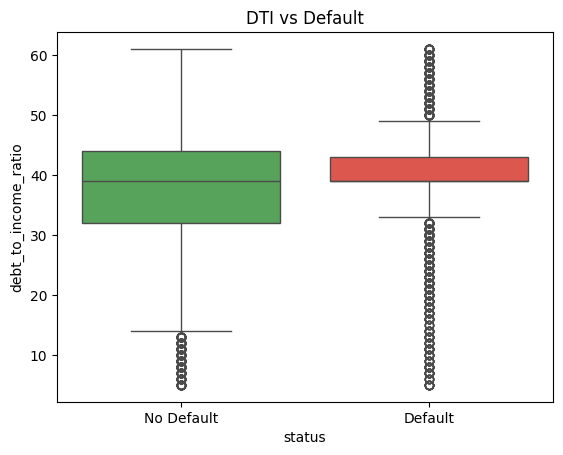

In [25]:
sns.boxplot(x='status', y='debt_to_income_ratio', data=df,hue='status',palette=palette,legend=False)
plt.title("DTI vs Default")
plt.xticks([0, 1], ['No Default', 'Default'])
plt.show()

### 📊 Observation:
The difference in DTI between default and non-default groups is modest and less pronounced than expected.

### 💡 Insight:
While the box plot suggests higher DTI borrowers trend toward default, the actual default rates tell a more nuanced story — explored in the final insights section below.

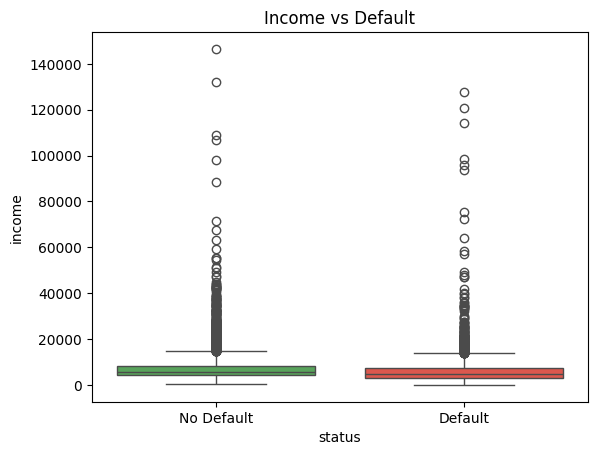

In [26]:
sns.boxplot(x='status', y='income', data=df,hue='status',palette=palette,legend=False)
plt.title("Income vs Default")
plt.xticks([0, 1], ['No Default', 'Default'])
plt.show()

### 📊 Observation:
Defaulted borrowers show lower median income compared to non-defaulted borrowers. Both groups contain significant high-income outliers, confirming the severe right skew noted in the distribution section.

### 💡 Insight:
Lower income borrowers default more frequently, but income alone is a weak standalone signal. Its predictive value strengthens when evaluated alongside DTI — a low income borrower with manageable debt is less risky than a moderate income borrower who is over-leveraged.



## Section: Combined Risk Segmentation
Combining LTV risk bucket and credit score bucket to identify borrower segments where multiple risk factors compound simultaneously.

In [10]:
df['combined_risk'] = df['ltv_risk_bucket'] + "_" + df['credit_score_bucket']

pd.crosstab(df['combined_risk'], df['status'], normalize='index').sort_values(by=1, ascending=False).head(10)

status,0,1
combined_risk,,
Moderate_Very Good,0.669856,0.330144
Moderate_Good,0.677033,0.322967
Moderate_Poor,0.681019,0.318981
Moderate_Excellent,0.686299,0.313701
Moderate_Fair,0.700000,0.300000
Very High_Poor,0.755981,0.244019
Very High_Good,0.759494,0.240506
Very High_Excellent,0.762366,0.237634
Very High_Fair,0.766990,0.233010


### 📊 Observation:
Moderate LTV segments consistently show the highest default rates across all credit score categories — with Moderate_Very Good at 33% being the highest. Notably, even Moderate LTV borrowers with Excellent credit default at 31.4%.
### 💡 Insight:
Risk is not solely driven by credit score.
Mid-range (Moderate) LTV loans exhibit unexpectedly high default rates, suggesting potential mispricing or risk underestimation.
Combining features provides deeper insights than analyzing variables independently.

## Trend: Default Rate by Region

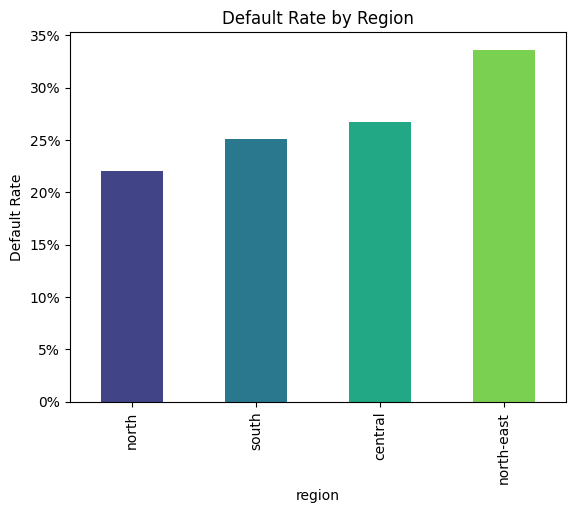

In [27]:
colors = sns.color_palette("viridis", n_colors=df['region'].nunique())
df.groupby('region')['status'].mean().sort_values().plot(kind='bar',color=colors)
plt.title('Default Rate by Region')
plt.ylabel('Default Rate')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.show()


### 📊 Observation:
North-East has the highest default rate at ~33%, more than 11 percentage points above North at ~22%. South and Central also exceed the portfolio average of 23.7%.

### 💡 Insight:
Regional default variation suggests local economic conditions and employment patterns influence repayment behaviour. The institution should apply region-specific risk weightings rather than a uniform national policy.

## Trend: Default Rate by Loan Purpose

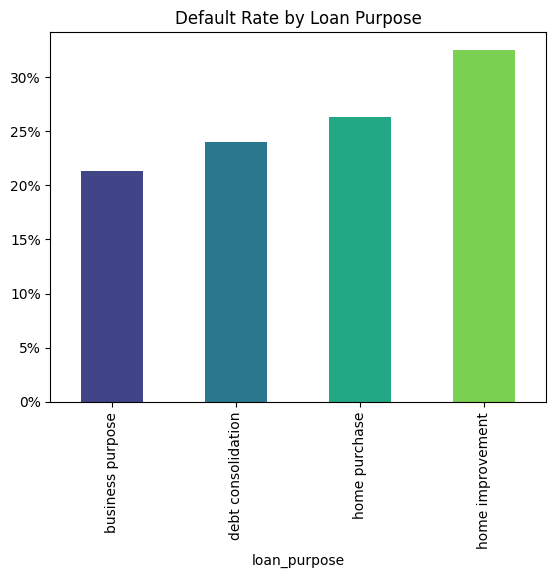

In [28]:
df.groupby('loan_purpose')['status'].mean().sort_values().plot(kind='bar',color=colors)
plt.title('Default Rate by Loan Purpose')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.show()


### 📊 Observation:
Home improvement loans have the highest default rate at ~32%, followed by home purchase at ~26%. Business purpose loans have the lowest at ~21%, below the portfolio average.


### 💡 Insight:
Home improvement borrowers take on additional debt on top of existing mortgages, increasing total financial burden. Business purpose loans show the lowest default rate — suggesting more structured repayment planning. Loan purpose-specific screening criteria would better reflect these risk differences.


## Trend: Default Rate by Age Group

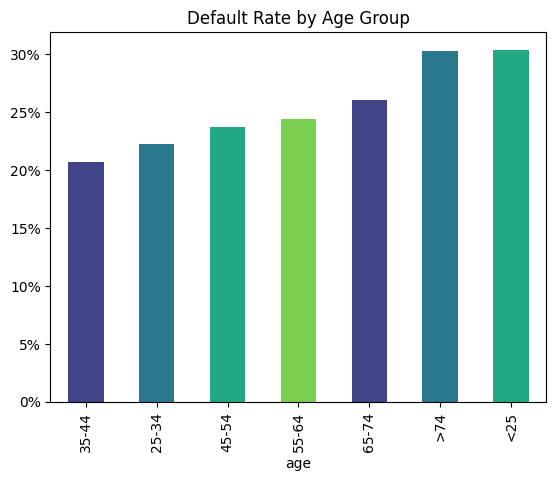

In [29]:

df.groupby('age')['status'].mean().sort_values().plot(kind='bar',color=colors)
plt.title('Default Rate by Age Group')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x*100:.0f}%'))
plt.show()

### 📊 Observation:
Borrowers under 25 and over 74 share the highest default rate at 30.4%, while the 35-44 age group has the lowest at 20.8%. Default risk follows a U-shaped pattern — highest at both extremes of age.
### 💡 Insight:
Young borrowers lack financial stability; older borrowers face declining income. The 35-44 group represents peak earning years and lowest risk. Both age extremes warrant stricter screening criteria.

## Section: Risk Factors — Loan Type

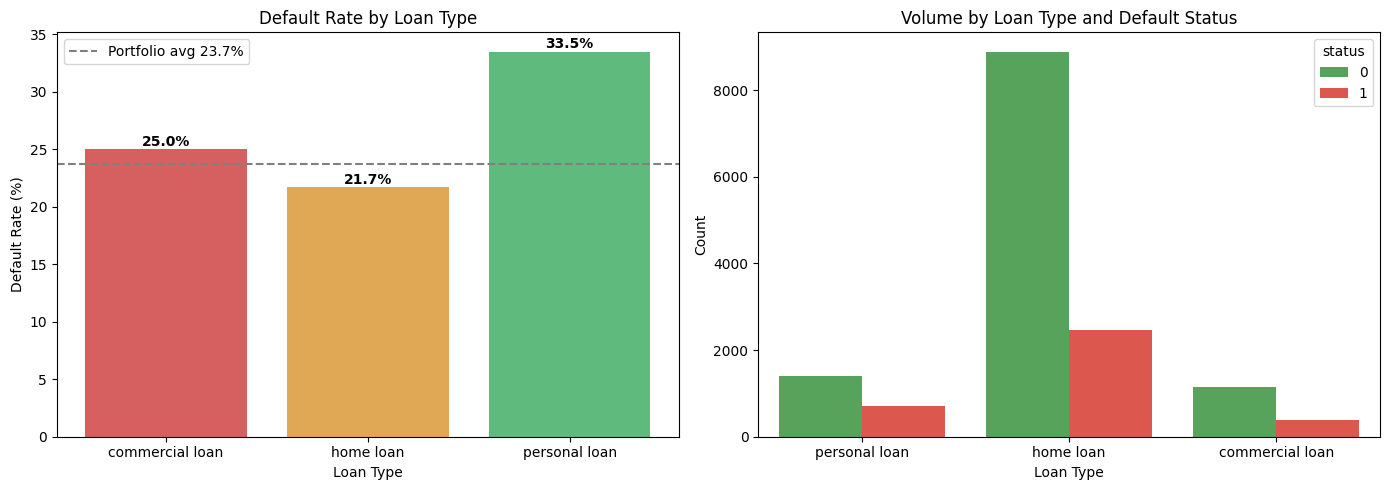

      loan_type  count  defaults  default_rate_%
commercial loan   1536       384            25.0
      home loan  11362      2470            21.7
  personal loan   2102       704            33.5


In [14]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lt_rates = default_rate_by('loan_type', df)
colors = ['#d65f5f','#e0a854','#5fba7d']
axes[0].bar(lt_rates['loan_type'], lt_rates['default_rate_%'], color=colors)
axes[0].axhline(23.7, color='gray', linestyle='--', label='Portfolio avg 23.7%')
axes[0].set_title('Default Rate by Loan Type')
axes[0].set_xlabel('Loan Type')
axes[0].set_ylabel('Default Rate (%)')
axes[0].legend()
for i, row in lt_rates.iterrows():
    axes[0].text(i, row['default_rate_%'] + 0.3, f"{row['default_rate_%']}%", ha='center', fontweight='bold')

sns.countplot(x='loan_type', hue='status', data=df, ax=axes[1], palette=palette)
axes[1].set_title('Volume by Loan Type and Default Status')
axes[1].set_xlabel('Loan Type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print(lt_rates.to_string(index=False))

### 📊 Observation:
Personal loans default at 33.5% — the highest among all loan types, nearly 12 percentage points above home loans at 21.7%. Commercial loans sit at 25%, slightly above the portfolio average.
### 💡 Insight:
Personal loans lack collateral backing, making them inherently higher risk when borrowers face financial stress. The institution should apply stricter income and DTI thresholds specifically for personal loan applicants rather than using a uniform approval policy across all loan types.

## Section: Risk Factors — Negative Amortisation


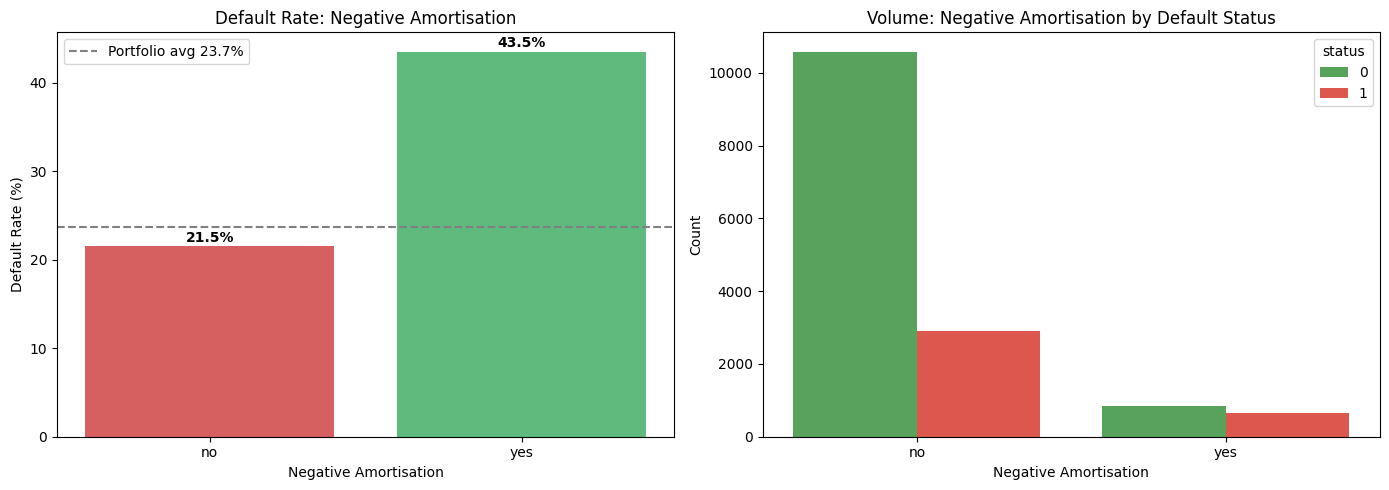

neg_ammortization  count  defaults  default_rate_%
               no  13488      2900            21.5
              yes   1512       658            43.5


In [15]:
neg_rates = default_rate_by('neg_ammortization', df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(neg_rates['neg_ammortization'], neg_rates['default_rate_%'],
            color=['#d65f5f','#5fba7d'])
axes[0].axhline(23.7, color='gray', linestyle='--', label='Portfolio avg 23.7%')
axes[0].set_title('Default Rate: Negative Amortisation')
axes[0].set_xlabel('Negative Amortisation')
axes[0].set_ylabel('Default Rate (%)')
axes[0].legend()
for i, row in neg_rates.iterrows():
    axes[0].text(i, row['default_rate_%'] + 0.5, f"{row['default_rate_%']}%", ha='center', fontweight='bold')

sns.countplot(x='neg_ammortization', hue='status', data=df, ax=axes[1], palette=palette)
axes[1].set_title('Volume: Negative Amortisation by Default Status')
axes[1].set_xlabel('Negative Amortisation')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()
print(neg_rates.to_string(index=False))

### 📊 Observation:
Negative amortisation loans default at 43.5% — nearly double the portfolio average of 23.7%.

### 💡 Insight:
Borrowers in these loans accumulate debt over time instead of reducing it, directly eroding repayment capacity. This is one of the highest-risk products in the portfolio and warrants immediate eligibility restrictions."



## Section: Risk Factors — Lump Sum Payment

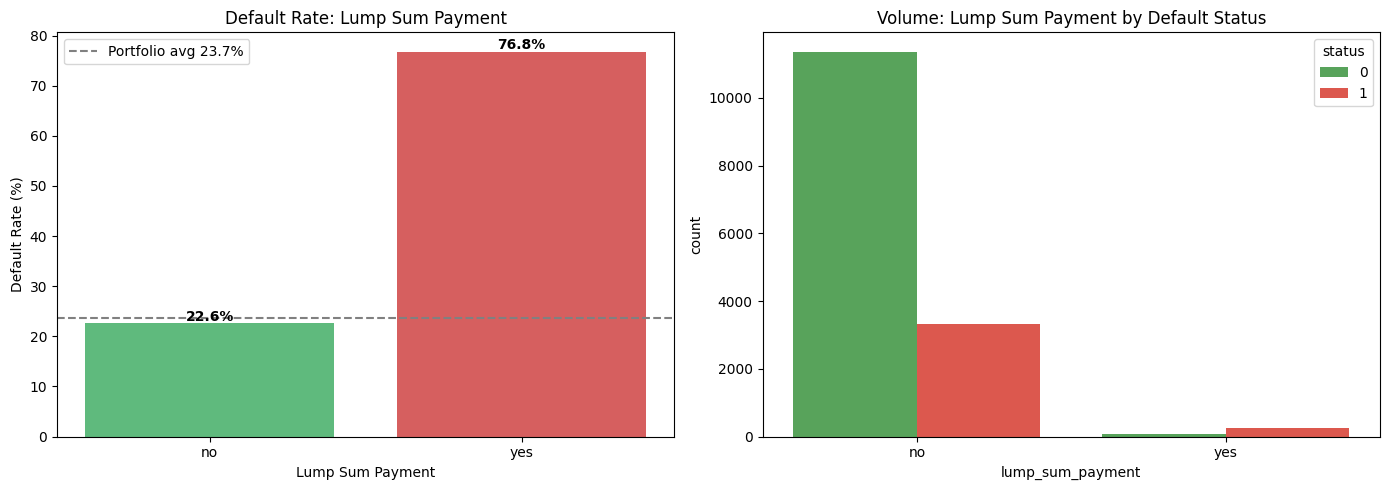

lump_sum_payment  count  defaults  default_rate_%
              no  14685      3316            22.6
             yes    315       242            76.8


In [16]:
lump_rates = default_rate_by('lump_sum_payment', df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(lump_rates['lump_sum_payment'], lump_rates['default_rate_%'],
            color=['#5fba7d','#d65f5f'])
axes[0].axhline(23.7, color='gray', linestyle='--', label='Portfolio avg 23.7%')
axes[0].set_title('Default Rate: Lump Sum Payment')
axes[0].set_xlabel('Lump Sum Payment')
axes[0].set_ylabel('Default Rate (%)')
axes[0].legend()
for i, row in lump_rates.iterrows():
    axes[0].text(i, row['default_rate_%'] + 0.5, f"{row['default_rate_%']}%", ha='center', fontweight='bold')

sns.countplot(x='lump_sum_payment', hue='status', data=df, ax=axes[1], palette=palette)
axes[1].set_title('Volume: Lump Sum Payment by Default Status')
plt.tight_layout()
plt.show()
print(lump_rates.to_string(index=False))

### 📊 Observation:
Lump sum payment loans default at 76.8% vs 22.6% for standard loans — a 54 percentage point gap. Only 315 loans in the portfolio have this structure, yet 242 of them defaulted.
### 💡 Insight:
Lump sum borrowers make no monthly payments, betting on a future windfall that frequently doesn't materialise. At 76.8% — 3x the portfolio average — this is the highest-risk product feature in the portfolio and warrants immediate restriction.

## Section: Risk Factors — Occupancy & Submission Channel

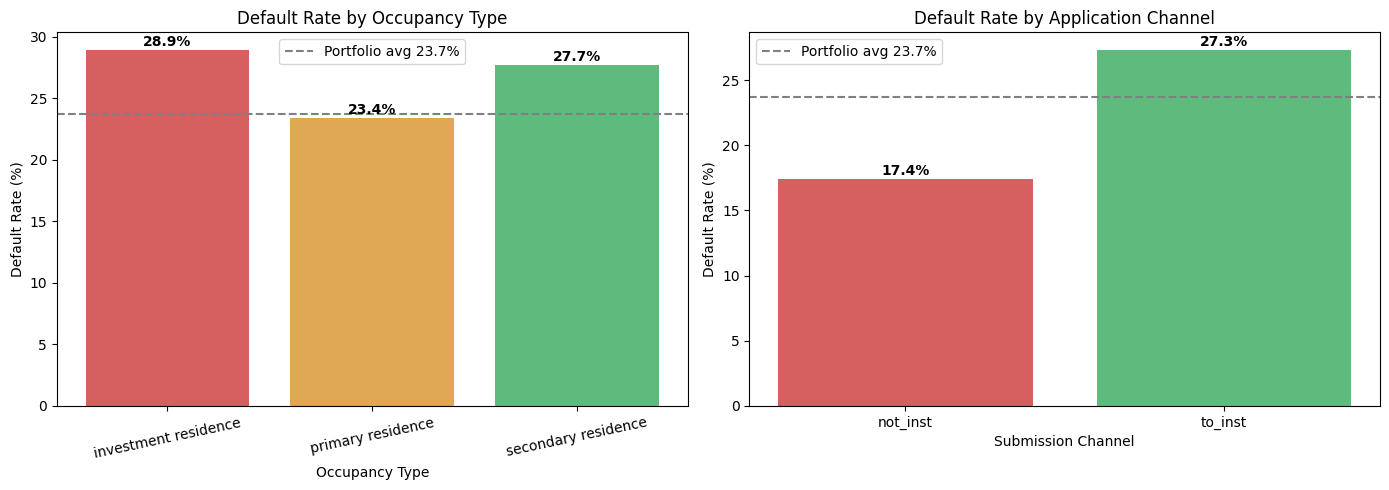

Occupancy type:
      occupancy_type  count  defaults  default_rate_%
investment residence    710       205            28.9
   primary residence  13994      3271            23.4
 secondary residence    296        82            27.7

Submission channel:
submission_of_application  count  defaults  default_rate_%
                 not_inst   5424       943            17.4
                  to_inst   9576      2615            27.3


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

occ_rates = default_rate_by('occupancy_type', df)
sub_rates = default_rate_by('submission_of_application', df)

axes[0].bar(occ_rates['occupancy_type'], occ_rates['default_rate_%'],
            color=['#d65f5f','#e0a854','#5fba7d'])
axes[0].axhline(23.7, color='gray', linestyle='--', label='Portfolio avg 23.7%')
axes[0].set_title('Default Rate by Occupancy Type')
axes[0].set_xlabel('Occupancy Type')
axes[0].set_ylabel('Default Rate (%)')
axes[0].tick_params(axis='x', rotation=12)
axes[0].legend()
for i, row in occ_rates.iterrows():
    axes[0].text(i, row['default_rate_%'] + 0.3, f"{row['default_rate_%']}%", ha='center', fontweight='bold')

axes[1].bar(sub_rates['submission_of_application'], sub_rates['default_rate_%'],
            color=['#d65f5f','#5fba7d'])
axes[1].axhline(23.7, color='gray', linestyle='--', label='Portfolio avg 23.7%')
axes[1].set_title('Default Rate by Application Channel')
axes[1].set_xlabel('Submission Channel')
axes[1].set_ylabel('Default Rate (%)')
axes[1].legend()
for i, row in sub_rates.iterrows():
    axes[1].text(i, row['default_rate_%'] + 0.3, f"{row['default_rate_%']}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
print("Occupancy type:")
print(occ_rates.to_string(index=False))
print("\nSubmission channel:")
print(sub_rates.to_string(index=False))

### 📊 Observation:
Investment residences default at 28.9% and institution-submitted applications at 27.3% — both above the 23.7% portfolio average. Non-institution submissions default at just 17.4%.
### 💡 Insight:
Investment property borrowers are more willing to walk away under financial stress. The 10-point gap in submission channel suggests institution-driven approvals may be bypassing rigorous screening — a process risk worth investigating.

## Section: Correlation Analysis

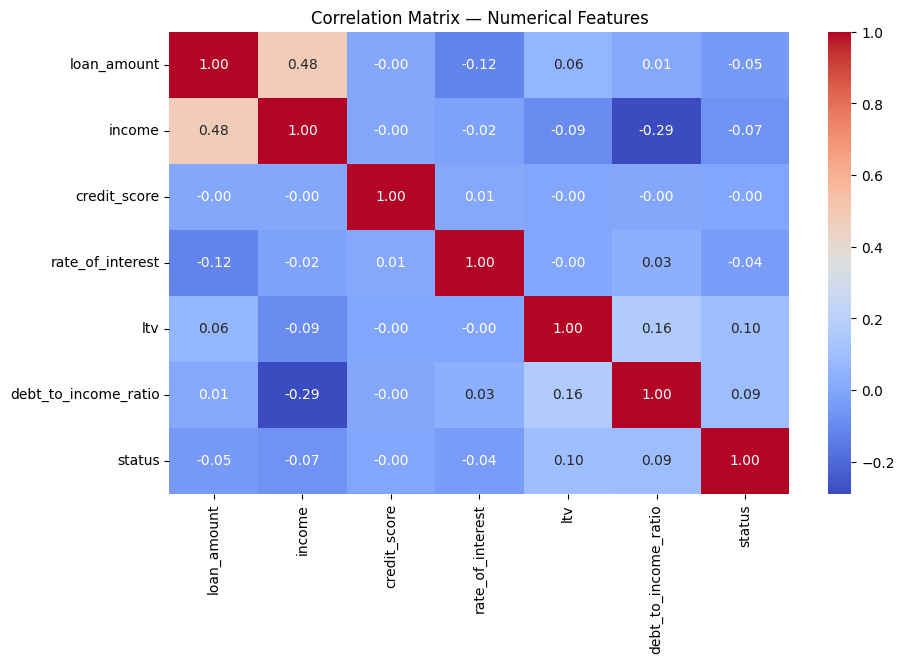

In [18]:

plt.figure(figsize=(10, 6))
numeric_cols = ['loan_amount', 'income', 'credit_score',
                'rate_of_interest', 'ltv', 'debt_to_income_ratio', 'status']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix — Numerical Features')
plt.show()

### 📊 Observation:
No single numerical variable shows a meaningful correlation with default status. The strongest correlations are LTV (0.10) and DTI (0.09) — both near zero.
### 💡 Insight:
Default risk in this portfolio cannot be explained by any single financial metric in isolation. This validates the combined risk segmentation approach and signals that the institution's current scoring model likely needs a multi-dimensional underwriting framework to accurately identify risky borrowers.

### Supporting Statistics for Final Insights

In [19]:
print("Default rate DTI >43%:", round(df[df['debt_to_income_ratio']>43]['status'].mean()*100, 1), "%")
print("Default rate DTI <=43%:", round(df[df['debt_to_income_ratio']<=43]['status'].mean()*100, 1), "%")
print("Default rate LTV High:", round(df[df['ltv_risk_bucket']=='High']['status'].mean()*100, 1), "%")
print("Default rate LTV Low:", round(df[df['ltv_risk_bucket']=='Low']['status'].mean()*100, 1), "%")
print("Default rate Poor credit:", round(df[df['credit_score_bucket']=='Poor']['status'].mean()*100, 1), "%")
print("Default rate Excellent credit:", round(df[df['credit_score_bucket']=='Excellent']['status'].mean()*100, 1), "%")

Default rate DTI >43%: 22.1 %
Default rate DTI <=43%: 24.3 %
Default rate LTV High: 17.1 %
Default rate LTV Low: 13.3 %
Default rate Poor credit: 23.9 %
Default rate Excellent credit: 23.7 %


## 💡 Final Insights

| # | Finding | Evidence |
|---|---------|----------|
| 1 | DTI is not a reliable standalone predictor | Borrowers below 43% DTI default at 24.3% — higher than those above (22.1%) |
| 2 | LTV is the most reliable numerical signal | High LTV borrowers default at 17.1% vs 13.3% for low LTV |
| 3 | Credit score has near-zero discriminatory power | Poor credit: 23.9% vs Excellent credit: 23.7% — virtually identical |
| 4 | Combined risk reveals structural mispricing | Moderate LTV dominates highest default segments regardless of credit score |
| 5 | Systemic underwriting problem detected | 23.7% portfolio default rate with no strong individual risk predictor |
| 6 | Lump sum payment is the strongest default signal | 76.8% default rate — 3x the portfolio average, immediate candidate for restriction |

>**Key Takeaway:** No single borrower financial metric reliably predicts default.
> However, product features — especially lump sum payment (76.8%) and negative amortisation (43.5%)
> — are the strongest risk signals and require immediate policy action.